In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.6 MB/s eta 0:00:00


In [2]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1


In [3]:
!touch carparts-seg.yaml

In [4]:
from ultralytics import YOLO
# load a pretrained segmentation  model like YOLO11n-seg
model=YOLO("yolo11n-seg.pt")

# Train the model on the Carparts Segmentation dataset
results = model.train(data="carparts-seg.yaml", epochs=10, imgsz=640)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=carparts-seg.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscr

In [5]:
# After training, validate the model
results = model.val()

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,839,053 parameters, 0 gradients, 9.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1165.8±527.8 MB/s, size: 40.5 KB)
val: Scanning /content/datasets/carparts-seg/labels/val.cache... 401 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 93.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.5it/s 10.2s
                   all        401       2042      0.582      0.796      0.688      0.566       0.59      0.793      0.699      0.544
           back_bumper         94         94      0.831      0.957      0.936      0.748      0.833      0.957      0.934      0.686
             back_door        158        159        0.8      0.887      0.907      0.775      0.811      0.887      0.907      0.748
            back_glass       

In [6]:
# Prediction on new images or videos
results = model.predict("/content/datasets/carparts-seg/images/test/te24_jpg.rf.6e76f7c8626f10eadf39852f5a6da104.jpg")


image 1/1 /content/datasets/carparts-seg/images/test/te24_jpg.rf.6e76f7c8626f10eadf39852f5a6da104.jpg: 640x640 1 back_door, 1 back_light, 1 front_door, 1 front_light, 1 wheel, 9.9ms
Speed: 0.9ms preprocess, 9.9ms inference, 8.4ms postprocess per image at shape (1, 3, 640, 640)


In [8]:
# plot the results on the original image

img_with_masks = results[0].plot()

# or save the plotted image
results[0].save('output_with_masks.jpg')

'output_with_masks.jpg'

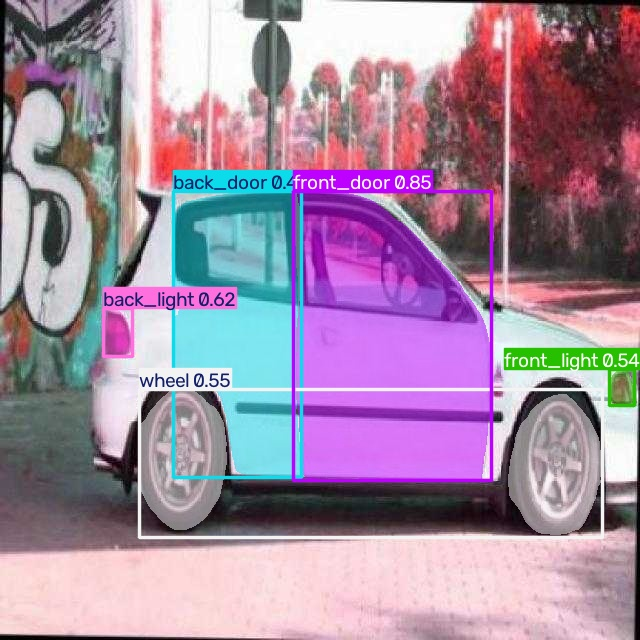

In [9]:
from IPython.display import Image, display
display(Image(filename='output_with_masks.jpg'))

## Another Example with Custom Dataset

In [10]:
!pip install roboflow

In [11]:
from roboflow import Roboflow
rf = Roboflow(api_key="DWkhqBMU6VvWaP5Glt64")
project = rf.workspace("university-bswxt").project("crack-bphdr")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crack-2 in yolov11:: 100%|██████████| 8070/8070 [00:01<00:00, 6728.14it/s]


In [ ]:
from ultralytics import YOLO

# load a pretrained segmentation  model like YOLO11n-seg
model=YOLO("yolo11n-seg.pt") # load a pretrained model


In [12]:
# Train the model on the Carparts Segmentation dataset
results = model.train(data="/content/crack-2/data.yaml", epochs=10, imgsz=640)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crack-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/segment/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tra

In [13]:
# After training validate
results = model.val()

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 993.6±197.7 MB/s, size: 23.9 KB)
val: Scanning /content/crack-2/valid/labels.cache... 200 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 46.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.2it/s 5.9s
                   all        200        249      0.883      0.727      0.784      0.582      0.777      0.614      0.621      0.201
Speed: 3.2ms preprocess, 6.5ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/segment/val-2


In [14]:
# preidction
results = model.predict("/content/crack-2/test/images/1686.rf.809fb1b51c607e5cf787e44ef4ddd7b8.jpg")


image 1/1 /content/crack-2/test/images/1686.rf.809fb1b51c607e5cf787e44ef4ddd7b8.jpg: 640x640 2 cracks, 9.9ms
Speed: 2.5ms preprocess, 9.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


In [16]:
# plot the result
img_with_masks = results[0].plot()

# or save the ploted image
results[0].save('output_with_masks1.jpg')

'output_with_masks1.jpg'

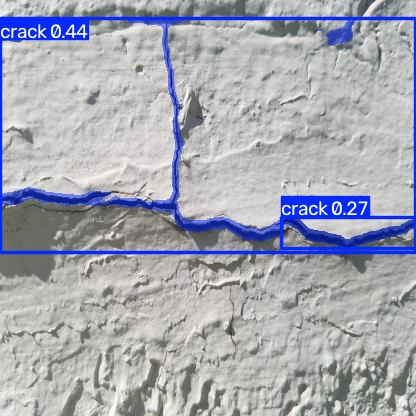

In [17]:
from IPython.display import Image, display
display(Image(filename='output_with_masks1.jpg'))

In [18]:
results = model.predict("/content/crack_image.jpeg")
# plot the result
img_with_masks2 = results[0].plot()

# or save the ploted image
results[0].save('output_with_masks2.jpg')


image 1/1 /content/crack_image.jpeg: 640x480 1 crack, 104.3ms
Speed: 3.5ms preprocess, 104.3ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 480)


'output_with_masks2.jpg'

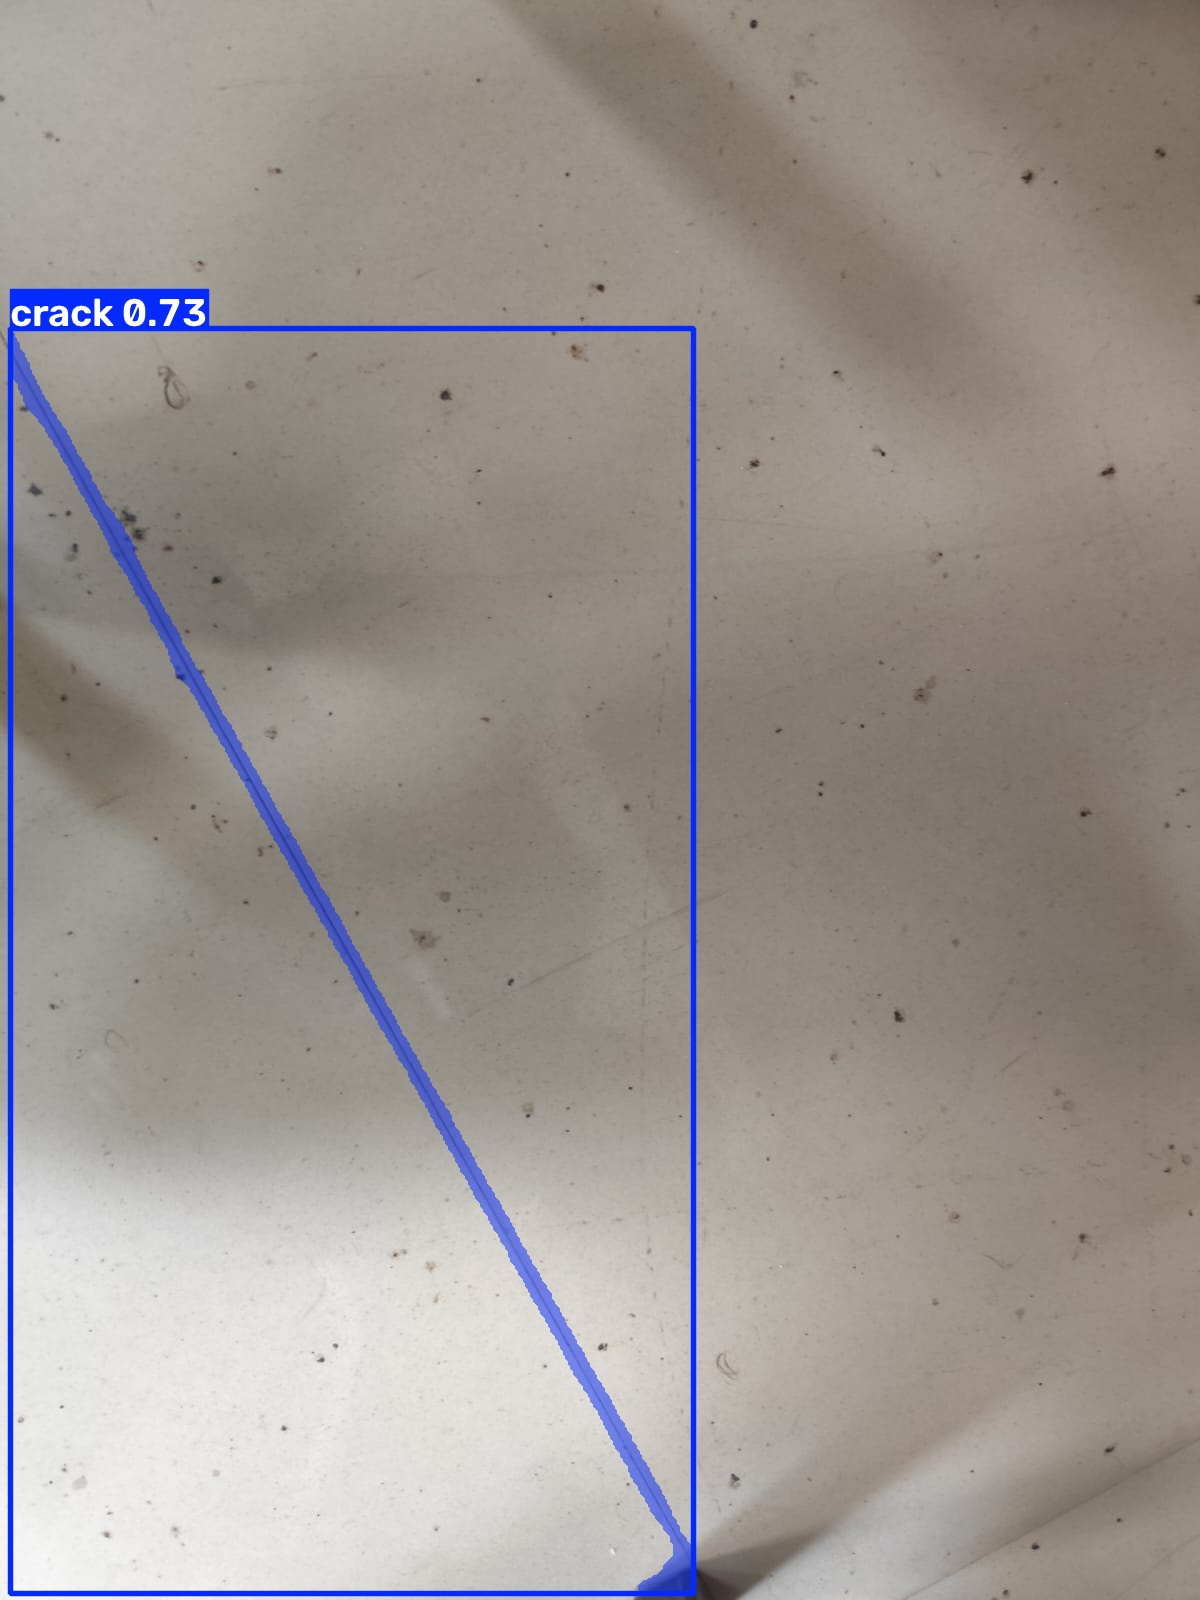

In [19]:
from IPython.display import Image, display
display(Image(filename='output_with_masks2.jpg'))